In [1]:
## Step 1: Import Libraries and Setup

import os, json, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

random.seed(42)
np.random.seed(42)

# ── Paths ────────────────────────────────────────────────────
OUTPUT_PATH        = '/kaggle/working'
DATASET_PATH_LOCAL = '/kaggle/working/dermnet_data'

# ── Auto-copy dataset if not already done ────────────────────
def find_and_copy_dataset():
    if os.path.exists(os.path.join(DATASET_PATH_LOCAL, 'train')):
        print(f"✓ Dataset ready: {DATASET_PATH_LOCAL}")
        return
    print("⚠️  Searching /kaggle/input for dataset ...")
    src = None
    for root, dirs, _ in os.walk('/kaggle/input'):
        if 'train' in dirs and 'test' in dirs:
            src = root
            break
    if src is None:
        raise FileNotFoundError("Dataset not found. Add DermNet via Notebook > Add Data.")
    print(f"Copying {src} → {DATASET_PATH_LOCAL} ...")
    os.makedirs(DATASET_PATH_LOCAL, exist_ok=True)
    shutil.copytree(src, DATASET_PATH_LOCAL, dirs_exist_ok=True)
    print("✓ Copy complete!")

find_and_copy_dataset()

train_path = os.path.join(DATASET_PATH_LOCAL, 'train')
val_path   = os.path.join(DATASET_PATH_LOCAL, 'val')
test_path  = os.path.join(DATASET_PATH_LOCAL, 'test')

# ── Auto-create val/ if missing ──────────────────────────────
def count_imgs(path):
    total = 0
    if os.path.exists(path):
        for cls in os.listdir(path):
            p = os.path.join(path, cls)
            if os.path.isdir(p):
                total += len([f for f in os.listdir(p)
                              if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

if count_imgs(val_path) == 0:
    from sklearn.model_selection import train_test_split
    from tqdm.notebook import tqdm
    print("⚠️  val/ missing — creating 80/20 split ...")
    os.makedirs(val_path, exist_ok=True)
    classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]
    moved = 0
    for cls in tqdm(classes, desc="Splitting val"):
        tc = os.path.join(train_path, cls)
        vc = os.path.join(val_path, cls)
        os.makedirs(vc, exist_ok=True)
        imgs = [f for f in os.listdir(tc) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(imgs) >= 5:
            _, v = train_test_split(imgs, test_size=0.2, random_state=42)
            for img in v:
                shutil.move(os.path.join(tc, img), os.path.join(vc, img))
            moved += len(v)
    print(f"✓ val/ created — {moved} images")
else:
    print(f"✓ val/ exists — {count_imgs(val_path)} images")

# ── Get NUM_CLASSES ──────────────────────────────────────────
class_map_path = os.path.join(OUTPUT_PATH, 'class_mapping.json')
if os.path.exists(class_map_path):
    with open(class_map_path) as f:
        class_mapping = json.load(f)
    NUM_CLASSES = class_mapping['num_classes']
else:
    NUM_CLASSES = len([d for d in os.listdir(train_path)
                       if os.path.isdir(os.path.join(train_path, d))])

print(f"\nTensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"Dataset    : {DATASET_PATH_LOCAL}")
print(f"Classes    : {NUM_CLASSES}")
print("\n✓ Setup complete!")


2026-02-21 06:26:53.812137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771655214.152614      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771655214.312569      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771655215.316731      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771655215.316779      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771655215.316782      24 computation_placer.cc:177] computation placer alr

⚠️  Searching /kaggle/input for dataset ...
Copying /kaggle/input/datasets/shubhamgoel27/dermnet → /kaggle/working/dermnet_data ...
✓ Copy complete!
⚠️  val/ missing — creating 80/20 split ...


Splitting val:   0%|          | 0/23 [00:00<?, ?it/s]

✓ val/ created — 3119 images

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Dataset    : /kaggle/working/dermnet_data
Classes    : 23

✓ Setup complete!


In [2]:
## Step 2: Set Model Configuration (EfficientNetB3)

IMG_HEIGHT    = 300   # EfficientNetB3 native size
IMG_WIDTH     = 300
IMG_CHANNELS  = 3

BATCH_SIZE    = 32
EPOCHS_PHASE1 = 10    # freeze phase
EPOCHS_PHASE2 = 40    # fine-tune phase
LEARNING_RATE = 0.001  # phase 1
FINE_TUNE_LR  = 1e-5   # phase 2
DROPOUT_RATE  = 0.4

print('Model Configuration (EfficientNetB3 Transfer Learning):')
print('=' * 55)
print(f'Input Shape   : ({IMG_HEIGHT}, {IMG_WIDTH}, {IMG_CHANNELS})')
print(f'Num Classes   : {NUM_CLASSES}')
print(f'Batch Size    : {BATCH_SIZE}')
print(f'Phase-1 Epochs: {EPOCHS_PHASE1}  (head only)')
print(f'Phase-2 Epochs: {EPOCHS_PHASE2}  (fine-tune top 30%)')
print(f'Phase-1 LR    : {LEARNING_RATE}')
print(f'Phase-2 LR    : {FINE_TUNE_LR}')
print('=' * 55)


Model Configuration (EfficientNetB3 Transfer Learning):
Input Shape   : (300, 300, 3)
Num Classes   : 23
Batch Size    : 32
Phase-1 Epochs: 10  (head only)
Phase-2 Epochs: 40  (fine-tune top 30%)
Phase-1 LR    : 0.001
Phase-2 LR    : 1e-05


In [3]:
## Step 3: Build EfficientNetB3 Transfer Learning Model

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, Model

input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Load EfficientNetB3 pretrained on ImageNet (no top)
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Phase 1: Freeze entire base model
base_model.trainable = False

# Build classification head
inputs  = layers.Input(shape=input_shape)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(DROPOUT_RATE)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

print(f'✓ EfficientNetB3 model built!')
print(f'  Base model layers : {len(base_model.layers)}')
print(f'  Output classes    : {NUM_CLASSES}')
print(f'  Base frozen       : True (Phase 1)')


I0000 00:00:1771655496.514805      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771655496.520868      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ EfficientNetB3 model built!
  Base model layers : 385
  Output classes    : 23
  Base frozen       : True (Phase 1)


In [4]:
## Step 4: Display Model Summary

# Display model summary
print("\nModel Architecture:")
print("=" * 80)
model.summary()
print("=" * 80)



Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,713,862 (44.68 MB)

 Trainable params: 927,255 (3.54 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [5]:
## Step 5: Compile Model (Phase 1 — head only)

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print('✓ Model compiled for Phase 1 (head only training)')
print(f'  Optimizer : Adam (lr={LEARNING_RATE})')
print(f'  Loss      : categorical_crossentropy')
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
total     = model.count_params()
print(f'  Trainable params : {trainable:,} / {total:,}')


✓ Model compiled for Phase 1 (head only training)
  Optimizer : Adam (lr=0.001)
  Loss      : categorical_crossentropy
  Trainable params : 927,255 / 11,713,862


✓ Model architecture diagram saved to: /kaggle/working/model_architecture.png


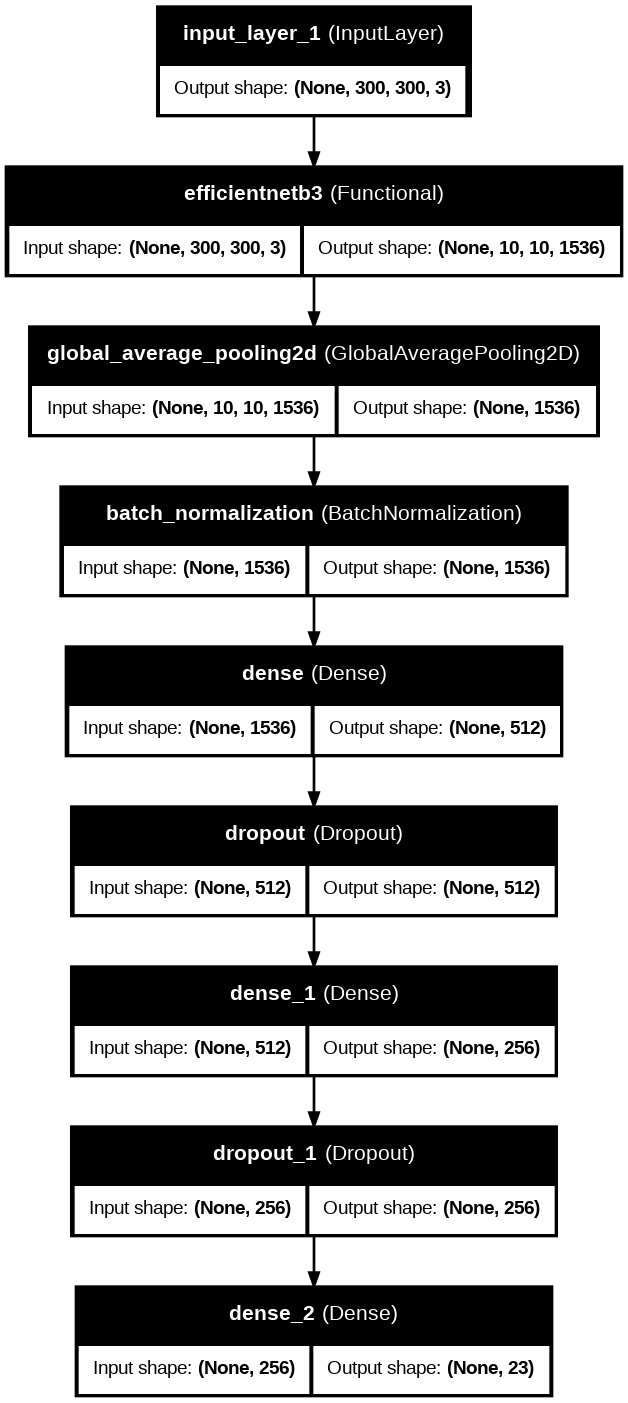

In [6]:
## Step 6: Visualize Model Architecture

# Visualize model architecture
arch_img_path = os.path.join(OUTPUT_PATH, 'model_architecture.png')

tf.keras.utils.plot_model(
    model,
    to_file=arch_img_path,
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=False,
    dpi=96
)
print(f"✓ Model architecture diagram saved to: {arch_img_path}")

from IPython.display import Image
Image(arch_img_path)

In [7]:
## Step 7: Calculate Model Parameters

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\nModel Parameters:")
print("=" * 50)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print("=" * 50)


Model Parameters:
Total parameters: 11,713,862
Trainable parameters: 927,255
Non-trainable parameters: 10,786,607


In [8]:
## Step 8: Save Model Architecture

import json as _json

model_config = {
    'model'             : 'EfficientNetB3',
    'input_shape'       : list(input_shape),
    'num_classes'       : NUM_CLASSES,
    'batch_size'        : BATCH_SIZE,
    'epochs_phase1'     : EPOCHS_PHASE1,
    'epochs_phase2'     : EPOCHS_PHASE2,
    'learning_rate_p1'  : LEARNING_RATE,
    'learning_rate_p2'  : FINE_TUNE_LR,
    'dropout_rate'      : DROPOUT_RATE,
    'optimizer'         : 'Adam',
    'loss'              : 'categorical_crossentropy',
    'total_parameters'  : int(model.count_params())
}

with open(os.path.join(OUTPUT_PATH, 'model_config.json'), 'w') as f:
    _json.dump(model_config, f, indent=4)
print('✓ Model configuration saved to model_config.json')

# Save model weights (Phase-1 init)
model.save(os.path.join(OUTPUT_PATH, 'efficientnet_phase1_init.h5'))
print('✓ Phase-1 init model saved.')


✓ Model configuration saved to model_config.json
✓ Phase-1 init model saved.


In [9]:
## Summary

#✅ **Completed Tasks:**
#- CNN architecture designed
#- Batch Normalization implemented
#- Adam Optimizer configured
#- Model compiled with appropriate metrics
#- Model architecture visualized and saved

#📊 **Model Details:**
#- **Input**: 224x224x3 RGB images
#- **Output**: 23 classes (skin diseases)
#- **Architecture**: 4 Conv blocks + 2 Dense layers
#- **Batch Normalization**: After each conv and dense layer
#- **Optimizer**: Adam (lr=0.001)
#- **Total Parameters**: ~15-20M (depends on NUM_CLASSES)

#🔑 **Key Features:**
#- Batch Normalization for stable training
#- Dropout for regularization
#- Adam optimizer for efficient learning
#- Categorical crossentropy for multi-class
